# Ed-Tech Partner Survey — Data Foundation & Metrics

**Author:** Ratna Suthar
**Goal:** design and implement a small data foundation that normalizes survey data across partner institutions, preserves partner-specific fields, and supports partner-level metrics.

**Context (white-labeled):** An education program is delivered through several partner institutions. Each partner runs the same pre/post student survey but exports it in a slightly different shape, and some partners add their own custom questions. This notebook builds the shared data foundation that makes the results comparable across partners.

This notebook is intentionally written as a small, reproducible pipeline rather than a polished production system. Clear assumptions and tradeoffs are documented inline.

## Part 1 — Generalized data model

### Design summary

I would model this as a small analytics warehouse with a **star-schema style foundation** plus a flexible survey response layer.

**Core idea:**  
- Student and partner attributes live in dimension tables.  
- Repeated behaviors and measurements live in fact tables.  
- Standard survey questions are mapped into shared fields for cross-partner metrics.  
- Partner-specific survey fields are preserved in a long response table rather than discarded or forced into a wide shared table.


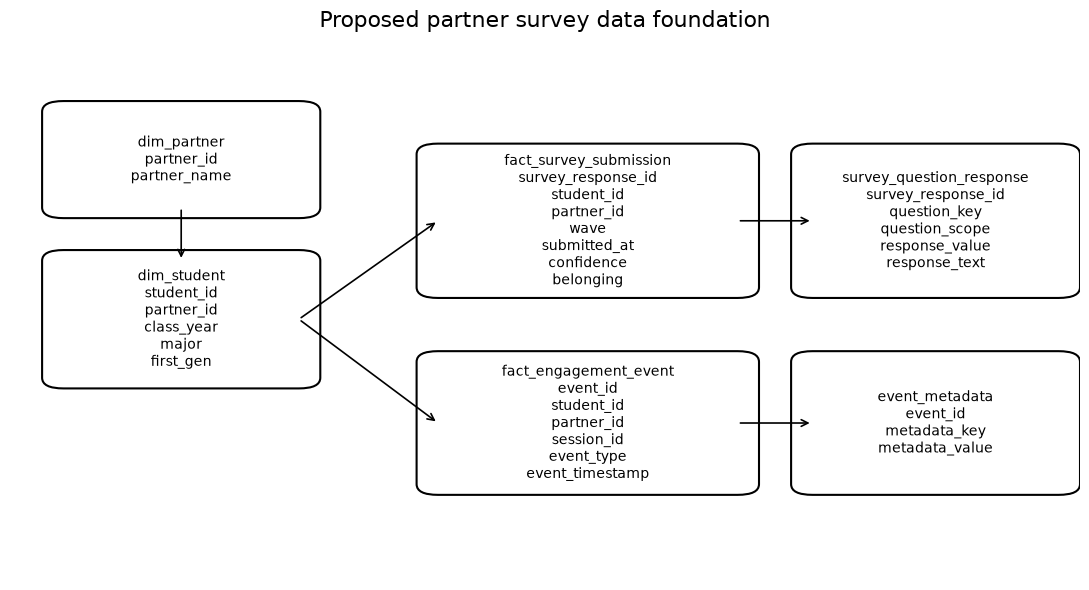

In [1]:
# Schema diagram embedded directly in notebook output

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_axis_off()

boxes = {
    "dim_partner": (0.05, 0.70, 0.22, 0.18, "dim_partner\npartner_id\npartner_name"),
    "dim_student": (0.05, 0.38, 0.22, 0.22, "dim_student\nstudent_id\npartner_id\nclass_year\nmajor\nfirst_gen"),
    "fact_survey_submission": (0.40, 0.55, 0.28, 0.25, "fact_survey_submission\nsurvey_response_id\nstudent_id\npartner_id\nwave\nsubmitted_at\nconfidence\nbelonging"),
    "fact_engagement_event": (0.40, 0.18, 0.28, 0.23, "fact_engagement_event\nevent_id\nstudent_id\npartner_id\nsession_id\nevent_type\nevent_timestamp"),
    "survey_question_response": (0.75, 0.55, 0.23, 0.25, "survey_question_response\nsurvey_response_id\nquestion_key\nquestion_scope\nresponse_value\nresponse_text"),
    "event_metadata": (0.75, 0.18, 0.23, 0.23, "event_metadata\nevent_id\nmetadata_key\nmetadata_value")
}

for name, (x, y, w, h, text) in boxes.items():
    rect = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02", linewidth=1.5, facecolor="white")
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10)

arrows = [
    ("dim_partner", "dim_student"),
    ("dim_student", "fact_survey_submission"),
    ("dim_student", "fact_engagement_event"),
    ("fact_survey_submission", "survey_question_response"),
    ("fact_engagement_event", "event_metadata")
]

for src, dst in arrows:
    x1, y1, w1, h1, _ = boxes[src]
    x2, y2, w2, h2, _ = boxes[dst]
    start = (x1 + w1, y1 + h1/2)
    end = (x2, y2 + h2/2)
    if src == "dim_partner" and dst == "dim_student":
        start = (x1 + w1/2, y1)
        end = (x2 + w2/2, y2 + h2)
    arrow = FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=12, linewidth=1.2)
    ax.add_patch(arrow)

ax.set_title("Proposed partner survey data foundation", fontsize=16, pad=15)
plt.tight_layout()
plt.show()

### Key tables and why they exist

| Table | Grain | Purpose |
|---|---|---|
| `dim_partner` | One row per partner | Canonical partner lookup; avoids inconsistent partner naming. |
| `dim_student` | One row per student | Student demographics/enrollment attributes used to slice metrics. |
| `fact_survey_submission` | One row per student per survey wave/submission | Normalized pre/post survey facts with shared metrics-ready fields like `confidence` and `belonging`. |
| `survey_question_response` | One row per survey submission per question | Preserves all survey responses, including custom partner-specific fields. |
| `fact_engagement_event` | One row per telemetry event | Activity/engagement event log for metrics such as lesson completion or dialogue participation. |
| `event_metadata` | One row per event metadata key/value | Optional scalable place for JSON fields like score or duration. |

### Handling partner-specific fields

Partner-specific fields should not be dropped. They should be stored in `survey_question_response` with:
- `question_scope = "standard"` for mapped cross-partner questions.
- `question_scope = "partner_specific"` for fields such as Partner B's `custom_q_peer_connection`.

For analysis-ready reporting, I create a compact `survey_unified` table with shared fields, while preserving the longer question-level table for partner-specific analysis.


## Part 2 — Minimal pipeline

In [2]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

# Provided synthetic assessment data lives in ./data
DATA_DIR = Path("data")

profiles = pd.read_csv(DATA_DIR / "student_profiles.csv")
survey_a_raw = pd.read_csv(DATA_DIR / "survey_partner_a.csv")
survey_b_raw = pd.read_csv(DATA_DIR / "survey_partner_b.csv")
events_raw = pd.read_csv(DATA_DIR / "interaction_events.csv")

for name, df in {
    "profiles": profiles,
    "survey_partner_a": survey_a_raw,
    "survey_partner_b": survey_b_raw,
    "interaction_events": events_raw
}.items():
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} columns")

profiles: 200 rows x 6 columns
survey_partner_a: 152 rows x 8 columns
survey_partner_b: 165 rows x 9 columns
interaction_events: 817 rows x 7 columns


In [3]:
# Normalize survey datasets into one shared schema.

def normalize_partner_a(df: pd.DataFrame) -> pd.DataFrame:
    out = df.rename(columns={
        "survey_time": "submitted_at",
        "survey_wave": "wave",
        "q1_confidence": "confidence",
        "q2_belonging": "belonging",
        "open_text": "reflection_text"
    }).copy()
    out["source_partner_file"] = "survey_partner_a.csv"
    out["custom_q_peer_connection"] = np.nan
    return out[[
        "student_id", "partner", "started_at", "submitted_at", "wave",
        "confidence", "belonging", "reflection_text",
        "custom_q_peer_connection", "source_partner_file"
    ]]

def normalize_partner_b(df: pd.DataFrame) -> pd.DataFrame:
    out = df.rename(columns={
        "user": "student_id",
        "institution": "partner",
        "submitted_at": "submitted_at",
        "confidence_rating": "confidence",
        "community_belonging": "belonging",
        "reflection_text": "reflection_text"
    }).copy()
    out["source_partner_file"] = "survey_partner_b.csv"
    return out[[
        "student_id", "partner", "started_at", "submitted_at", "wave",
        "confidence", "belonging", "reflection_text",
        "custom_q_peer_connection", "source_partner_file"
    ]]

survey_unified_raw = pd.concat([
    normalize_partner_a(survey_a_raw),
    normalize_partner_b(survey_b_raw)
], ignore_index=True)

# Parse dates and enforce basic types.
for col in ["started_at", "submitted_at"]:
    survey_unified_raw[col] = pd.to_datetime(survey_unified_raw[col], errors="coerce")

survey_unified_raw["confidence"] = pd.to_numeric(survey_unified_raw["confidence"], errors="coerce")
survey_unified_raw["belonging"] = pd.to_numeric(survey_unified_raw["belonging"], errors="coerce")
survey_unified_raw["wave"] = survey_unified_raw["wave"].str.lower().str.strip()

survey_unified_raw.head()


,student_id,partner,started_at,submitted_at,wave,confidence,belonging,reflection_text,custom_q_peer_connection,source_partner_file
0,S0159,PartnerA,2023-09-01 12:07:00,2023-09-01 12:14:29,pre,2,4,NaN,NaN,survey_partner_a.csv
1,S0051,PartnerA,2023-11-21 19:48:00,2023-11-21 20:01:34,post,4,4,I wish we had more time for small-group work.,NaN,survey_partner_a.csv
2,S0053,PartnerA,2023-08-29 15:35:00,2023-08-29 15:49:01,pre,2,3,NaN,NaN,survey_partner_a.csv
3,S0072,PartnerA,2023-08-25 15:49:00,2023-08-25 15:51:36,pre,2,3,The dialogue exercises were eye-opening.,NaN,survey_partner_a.csv
4,S0064,PartnerA,2023-11-25 18:44:00,2023-11-25 18:45:50,post,2,5,The dialogue exercises were eye-opening.,NaN,survey_partner_a.csv


In [4]:
# Data quality checks

valid_waves = {"pre", "post"}
dq_results = {
    "profiles_student_id_unique": profiles["student_id"].is_unique,
    "events_event_id_unique": events_raw["event_id"].is_unique,
    "survey_valid_waves": set(survey_unified_raw["wave"].dropna().unique()).issubset(valid_waves),
    "survey_confidence_in_1_to_5": survey_unified_raw["confidence"].dropna().between(1, 5).all(),
    "survey_belonging_in_1_to_5": survey_unified_raw["belonging"].dropna().between(1, 5).all(),
    "survey_submitted_after_started": (survey_unified_raw["submitted_at"] >= survey_unified_raw["started_at"]).all()
}

pd.DataFrame([
    {"check": k, "passed": bool(v)}
    for k, v in dq_results.items()
])


,check,passed
0,profiles_student_id_unique,True
1,events_event_id_unique,True
2,survey_valid_waves,True
3,survey_confidence_in_1_to_5,False
4,survey_belonging_in_1_to_5,False
5,survey_submitted_after_started,True


In [5]:
# Inspect duplicate survey submissions and orphan survey records.

duplicate_survey_rows = (
    survey_unified_raw
    .duplicated(subset=["student_id", "partner", "wave"], keep=False)
)

orphan_survey_rows = ~survey_unified_raw["student_id"].isin(profiles["student_id"])

print("Duplicate student/partner/wave survey rows:", int(duplicate_survey_rows.sum()))
print("Survey rows without matching student profile:", int(orphan_survey_rows.sum()))

survey_unified_raw.loc[duplicate_survey_rows | orphan_survey_rows].sort_values(
    ["student_id", "partner", "wave", "submitted_at"]
).head(10)


Duplicate student/partner/wave survey rows: 28
Survey rows without matching student profile: 3


,student_id,partner,started_at,submitted_at,wave,confidence,belonging,reflection_text,custom_q_peer_connection,source_partner_file
17,S0006,PartnerA,2023-11-17 12:36:00,2023-11-17 12:37:34,post,3,4,NaN,NaN,survey_partner_a.csv
85,S0006,PartnerA,2023-11-17 12:36:00,2023-11-17 12:37:34,post,3,4,NaN,NaN,survey_partner_a.csv
31,S0017,PartnerA,2023-08-31 09:06:00,2023-08-31 09:13:18,pre,3,4,NaN,NaN,survey_partner_a.csv
113,S0017,PartnerA,2023-08-31 09:06:00,2023-08-31 09:13:18,pre,3,4,NaN,NaN,survey_partner_a.csv
143,S0024,PartnerA,2023-08-29 21:01:00,2023-08-29 21:08:32,pre,3,5,I learned a lot about perspective-taking.,NaN,survey_partner_a.csv
94,S0024,PartnerA,2023-08-29 21:12:32,2023-08-29 21:12:32,pre,4,5,I learned a lot about perspective-taking.,NaN,survey_partner_a.csv
82,S0027,PartnerA,2023-11-24 16:54:00,2023-11-24 17:03:46,post,3,5,The dialogue exercises were eye-opening.,NaN,survey_partner_a.csv
103,S0027,PartnerA,2023-11-24 16:54:00,2023-11-24 17:03:46,post,3,5,The dialogue exercises were eye-opening.,NaN,survey_partner_a.csv
160,S0028,PartnerB,2023-11-25 17:40:00,2023-11-25 17:50:27,post,4,5,I wish we had more time for small-group work.,4.0,survey_partner_b.csv
161,S0028,PartnerB,2023-11-25 17:40:00,2023-11-25 17:50:27,post,4,5,I wish we had more time for small-group work.,4.0,survey_partner_b.csv


### Assumptions for pipeline

1. `student_profiles.student_id` is the enrollment roster and is the source of truth for students.
2. Survey rows without a matching student profile are excluded from cross-partner reporting, but flagged above as data quality issues.
3. If a student has multiple submissions for the same partner and wave, I keep the latest `submitted_at` record. In production, I would confirm whether this is correct or whether the first complete submission should be retained.
4. The shared survey constructs are `confidence` and `belonging`. Partner B's `custom_q_peer_connection` is preserved as partner-specific data.


In [6]:
# Deduplicate survey rows after excluding orphan records.

survey_unified = (
    survey_unified_raw
    .loc[~orphan_survey_rows]
    .sort_values(["student_id", "partner", "wave", "submitted_at"])
    .drop_duplicates(subset=["student_id", "partner", "wave"], keep="last")
    .reset_index(drop=True)
)

# Add a stable survey response id.
survey_unified["survey_response_id"] = (
    "SR" + survey_unified.index.astype(str).str.zfill(5)
)

survey_unified = survey_unified[[
    "survey_response_id", "student_id", "partner", "started_at", "submitted_at", "wave",
    "confidence", "belonging", "reflection_text",
    "custom_q_peer_connection", "source_partner_file"
]]

survey_unified.head()


,survey_response_id,student_id,partner,started_at,submitted_at,wave,confidence,belonging,reflection_text,custom_q_peer_connection,source_partner_file
0,SR00000,S0000,PartnerA,2023-11-16 11:46:00,2023-11-16 11:55:19,post,4,2,NaN,NaN,survey_partner_a.csv
1,SR00001,S0001,PartnerA,2023-08-27 18:44:00,2023-08-27 18:57:50,pre,2,2,I learned a lot about perspective-taking.,NaN,survey_partner_a.csv
2,SR00002,S0002,PartnerA,2023-11-25 11:14:00,2023-11-25 11:26:15,post,2,4,I learned a lot about perspective-taking.,NaN,survey_partner_a.csv
3,SR00003,S0003,PartnerB,2023-11-19 13:25:00,2023-11-19 13:28:27,post,4,5,NaN,3.0,survey_partner_b.csv
4,SR00004,S0004,PartnerB,2023-11-15 13:49:00,2023-11-15 13:50:39,post,5,5,The dialogue exercises were eye-opening.,3.0,survey_partner_b.csv


In [7]:
# Create question-level long table that preserves standard and partner-specific responses.

standard_question_map = {
    "confidence": "confidence",
    "belonging": "belonging",
    "reflection_text": "reflection_text"
}

partner_specific_question_map = {
    "custom_q_peer_connection": "peer_connection"
}

response_rows = []

for _, row in survey_unified.iterrows():
    for source_col, question_key in standard_question_map.items():
        value = row[source_col]
        if pd.notna(value):
            response_rows.append({
                "survey_response_id": row["survey_response_id"],
                "student_id": row["student_id"],
                "partner": row["partner"],
                "wave": row["wave"],
                "question_key": question_key,
                "question_scope": "standard",
                "response_value": value if source_col != "reflection_text" else np.nan,
                "response_text": value if source_col == "reflection_text" else np.nan
            })
    for source_col, question_key in partner_specific_question_map.items():
        value = row[source_col]
        if pd.notna(value):
            response_rows.append({
                "survey_response_id": row["survey_response_id"],
                "student_id": row["student_id"],
                "partner": row["partner"],
                "wave": row["wave"],
                "question_key": question_key,
                "question_scope": "partner_specific",
                "response_value": value,
                "response_text": np.nan
            })

survey_question_response = pd.DataFrame(response_rows)
survey_question_response.head(12)


,survey_response_id,student_id,partner,wave,question_key,question_scope,response_value,response_text
0,SR00000,S0000,PartnerA,post,confidence,standard,4.0,NaN
1,SR00000,S0000,PartnerA,post,belonging,standard,2.0,NaN
2,SR00001,S0001,PartnerA,pre,confidence,standard,2.0,NaN
3,SR00001,S0001,PartnerA,pre,belonging,standard,2.0,NaN
4,SR00001,S0001,PartnerA,pre,reflection_text,standard,NaN,I learned a lot about perspective-taking.
5,SR00002,S0002,PartnerA,post,confidence,standard,2.0,NaN
6,SR00002,S0002,PartnerA,post,belonging,standard,4.0,NaN
7,SR00002,S0002,PartnerA,post,reflection_text,standard,NaN,I learned a lot about perspective-taking.
8,SR00003,S0003,PartnerB,post,confidence,standard,4.0,NaN
9,SR00003,S0003,PartnerB,post,belonging,standard,5.0,NaN


In [8]:
# Normalize engagement events and parse metadata.

events = events_raw.rename(columns={"partner_id": "partner"}).copy()
events["event_timestamp"] = pd.to_datetime(events["event_timestamp"], errors="coerce")

def safe_parse_json(x):
    if pd.isna(x):
        return {}
    try:
        return json.loads(x)
    except Exception:
        return {}

metadata_rows = []
for _, row in events.iterrows():
    parsed = safe_parse_json(row["metadata"])
    for key, value in parsed.items():
        metadata_rows.append({
            "event_id": row["event_id"],
            "metadata_key": key,
            "metadata_value": value
        })

event_metadata = pd.DataFrame(metadata_rows)

print("events:", events.shape)
print("event_metadata:", event_metadata.shape)
event_metadata.head()


events: (817, 7)
event_metadata: (340, 3)


,event_id,metadata_key,metadata_value
0,E10002,score,65
1,E10003,duration_sec,82
2,E10011,duration_sec,194
3,E10012,duration_sec,125
4,E10013,score,51


In [9]:
# Create a compact analysis-ready table at student-partner grain.

student_base = profiles.rename(columns={"partner": "profile_partner"}).copy()

survey_completion = (
    survey_unified
    .pivot_table(
        index=["student_id", "partner"],
        columns="wave",
        values=["confidence", "belonging"],
        aggfunc="first"
    )
)

survey_completion.columns = [f"{metric}_{wave}" for metric, wave in survey_completion.columns]
survey_completion = survey_completion.reset_index()

student_event_features = (
    events
    .groupby(["student_id", "partner"])
    .agg(
        total_events=("event_id", "count"),
        lesson_completes=("event_type", lambda s: (s == "lesson_complete").sum()),
        dialogue_joins=("event_type", lambda s: (s == "dialogue_join").sum()),
        reflection_submits=("event_type", lambda s: (s == "reflection_submit").sum()),
        active_days=("event_timestamp", lambda s: s.dt.date.nunique())
    )
    .reset_index()
)

analysis_ready = (
    student_base
    .merge(survey_completion, left_on=["student_id", "profile_partner"], right_on=["student_id", "partner"], how="left")
    .drop(columns=["partner"])
    .rename(columns={"profile_partner": "partner"})
    .merge(student_event_features, on=["student_id", "partner"], how="left")
)

for col in ["total_events", "lesson_completes", "dialogue_joins", "reflection_submits", "active_days"]:
    analysis_ready[col] = analysis_ready[col].fillna(0).astype(int)

analysis_ready["has_pre_and_post"] = (
    analysis_ready["confidence_pre"].notna() &
    analysis_ready["confidence_post"].notna() &
    analysis_ready["belonging_pre"].notna() &
    analysis_ready["belonging_post"].notna()
)

analysis_ready["confidence_change"] = analysis_ready["confidence_post"] - analysis_ready["confidence_pre"]
analysis_ready["belonging_change"] = analysis_ready["belonging_post"] - analysis_ready["belonging_pre"]
analysis_ready["completed_at_least_one_lesson"] = analysis_ready["lesson_completes"] > 0
analysis_ready["joined_at_least_one_dialogue"] = analysis_ready["dialogue_joins"] > 0

analysis_ready.head()


,student_id,partner,class_year,major,first_gen,created_at,belonging_post,belonging_pre,confidence_post,confidence_pre,total_events,lesson_completes,dialogue_joins,reflection_submits,active_days,has_pre_and_post,confidence_change,belonging_change,completed_at_least_one_lesson,joined_at_least_one_dialogue
0,S0000,PartnerA,2024,Econ,no,2023-08-29,2.0,NaN,4.0,NaN,5,1,1,2,5,False,NaN,NaN,True,True
1,S0001,PartnerA,2026,Bio,yes,2023-08-11,NaN,2.0,NaN,2.0,6,0,0,3,5,False,NaN,NaN,False,False
2,S0002,PartnerA,2024,CS,yes,2023-08-03,4.0,NaN,2.0,NaN,6,1,0,2,5,False,NaN,NaN,True,False
3,S0003,PartnerB,2024,Bio,no,2023-08-30,5.0,NaN,4.0,NaN,4,0,0,2,4,False,NaN,NaN,False,False
4,S0004,PartnerB,2025,CS,NaN,2023-08-01,5.0,4.0,5.0,3.0,1,0,0,0,1,True,2.0,1.0,False,False


## Part 3 — Define and compute metrics

I compute three partner-level metrics:

1. **Matched confidence change**  
   - Numerator: sum of `post confidence - pre confidence` among students with both pre and post surveys.  
   - Denominator: number of students with matched pre and post confidence responses.  
   - Scope: enrolled students with valid matched survey records.

2. **Matched belonging change**  
   - Numerator: sum of `post belonging - pre belonging` among students with both pre and post surveys.  
   - Denominator: number of students with matched pre and post belonging responses.  
   - Scope: enrolled students with valid matched survey records.

3. **Lesson completion rate**  
   - Numerator: number of enrolled students with at least one `lesson_complete` event.  
   - Denominator: number of enrolled students in that partner.  
   - Scope: enrolled students in `student_profiles`; incorporates engagement data.


In [10]:
metrics = (
    analysis_ready
    .groupby("partner")
    .agg(
        enrolled_students=("student_id", "nunique"),
        matched_survey_students=("has_pre_and_post", "sum"),
        avg_confidence_change=("confidence_change", "mean"),
        avg_belonging_change=("belonging_change", "mean"),
        lesson_completion_rate=("completed_at_least_one_lesson", "mean"),
        dialogue_participation_rate=("joined_at_least_one_dialogue", "mean"),
        avg_events_per_student=("total_events", "mean")
    )
    .reset_index()
)

metrics["lesson_completion_rate"] = metrics["lesson_completion_rate"].round(3)
metrics["dialogue_participation_rate"] = metrics["dialogue_participation_rate"].round(3)
metrics["avg_confidence_change"] = metrics["avg_confidence_change"].round(3)
metrics["avg_belonging_change"] = metrics["avg_belonging_change"].round(3)
metrics["avg_events_per_student"] = metrics["avg_events_per_student"].round(2)

metrics


,partner,enrolled_students,matched_survey_students,avg_confidence_change,avg_belonging_change,lesson_completion_rate,dialogue_participation_rate,avg_events_per_student
0,PartnerA,100,53,0.585,0.189,0.61,0.59,4.13
1,PartnerB,100,59,0.390,0.644,0.54,0.52,4.04


In [11]:
# Slightly more explicit metric table with numerator/denominator fields for reporting.

report_rows = []

for partner, df in analysis_ready.groupby("partner"):
    enrolled = df["student_id"].nunique()
    matched_conf = df["confidence_change"].notna().sum()
    matched_belong = df["belonging_change"].notna().sum()
    lesson_n = df["completed_at_least_one_lesson"].sum()

    report_rows.extend([
        {
            "partner": partner,
            "metric": "matched_confidence_change",
            "numerator": df["confidence_change"].sum(skipna=True),
            "denominator": matched_conf,
            "value": df["confidence_change"].mean(skipna=True)
        },
        {
            "partner": partner,
            "metric": "matched_belonging_change",
            "numerator": df["belonging_change"].sum(skipna=True),
            "denominator": matched_belong,
            "value": df["belonging_change"].mean(skipna=True)
        },
        {
            "partner": partner,
            "metric": "lesson_completion_rate",
            "numerator": lesson_n,
            "denominator": enrolled,
            "value": lesson_n / enrolled if enrolled else np.nan
        }
    ])

metric_definitions_and_values = pd.DataFrame(report_rows)
metric_definitions_and_values["value"] = metric_definitions_and_values["value"].round(3)
metric_definitions_and_values


,partner,metric,numerator,denominator,value
0,PartnerA,matched_confidence_change,31.0,53,0.585
1,PartnerA,matched_belonging_change,10.0,53,0.189
2,PartnerA,lesson_completion_rate,61.0,100,0.610
3,PartnerB,matched_confidence_change,23.0,59,0.390
4,PartnerB,matched_belonging_change,38.0,59,0.644
5,PartnerB,lesson_completion_rate,54.0,100,0.540


### Interpretation and caveats

- Confidence and belonging changes are calculated only for students with matched pre/post responses, so they may not represent all enrolled students.
- Partner-level comparison is possible because Partner A and Partner B survey fields were mapped into shared constructs.
- Engagement metrics use all enrolled students as the denominator; this makes low/no activity visible instead of only describing active users.
- The sample data contains duplicate survey submissions and orphan survey records. I handled these with simple rules, but in production I would clarify the intended business logic.


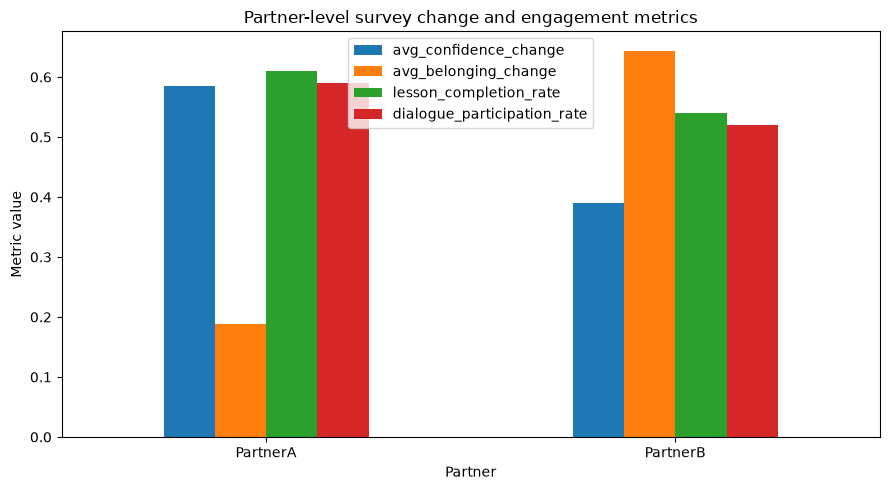

In [12]:
# Optional: visualize partner metrics for quick reporting.

import matplotlib.pyplot as plt

plot_df = metrics.set_index("partner")[[
    "avg_confidence_change",
    "avg_belonging_change",
    "lesson_completion_rate",
    "dialogue_participation_rate"
]]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Partner-level survey change and engagement metrics")
ax.set_xlabel("Partner")
ax.set_ylabel("Metric value")
ax.legend(loc="best")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Part 4 — Reflection

**How does your design scale to 10 or more partners?**  
- New partners can be added by creating a small source-to-canonical field mapping, while keeping shared constructs in `fact_survey_submission` and custom fields in `survey_question_response`.

**How would you handle new survey questions?**  
- I would add them to a question mapping table. If they map to a shared construct, they become comparable metrics; if not, they remain preserved as partner-specific long-form responses.

**What tradeoffs did you make?**  
- I prioritized a clear, minimal model over a fully productionized pipeline. I kept the unified survey table compact for metric computation while also creating a longer response table to avoid losing custom fields.

**What would you improve with more time?**  
- I would add a formal data dictionary, stronger validation tests, configurable partner mapping files, and a dbt-style staging/intermediate/mart structure with automated checks.


## AI Usage Log

**AI tools used:** ChatGPT, GPT-5.5 Thinking.

| Interaction | Prompt or paraphrase | Response summary | How I used it |
|---|---|---|---|
| 1 | Help me design this data-foundation notebook, especially the schema and pipeline. | Suggested a star-schema style model with student/partner dimensions, survey and engagement fact tables, and a long survey response table for partner-specific fields. | Adapted the structure and wrote my own final schema explanation. |
| 2 | Help me normalize Partner A and Partner B survey fields into one schema. | Suggested renaming partner-specific columns into canonical fields such as `student_id`, `partner`, `wave`, `confidence`, `belonging`, and `reflection_text`. | Used the mapping idea and implemented it in pandas functions. |
| 3 | What metrics should I compute that are comparable across partners and include engagement? | Suggested matched pre/post survey change and an event-based metric such as lesson completion rate. | Used these metrics and added explicit numerator/denominator reporting. |
| 4 | What caveats should I mention? | Suggested noting duplicate survey rows, orphan records, matched-survey bias, and denominator choices for engagement metrics. | Adapted these into the assumptions, interpretation, and reflection sections. |